# Valid credal sets

In [1]:
import os
import pickle
import sys

root_path = os.path.abspath('..')
sys.path.append(root_path)
with open(os.path.join(root_path, "all_results", "illustration", "res.pkl"), 'rb') as f:
    all_data = pickle.load(f)

In [5]:
from src.paper_plots import colorblind_codes, figsizes, sns_contexts, make_full_page_figure
import matplotlib.pyplot as plt

# Unknown Validity 

0.Credal Coverage Plots

In [2]:
from probly.metrics import coverage_convex_hull


model_seed = 3
gammas = [0.0, 0.2, 0.4, 0.6, 0.8]


100%|██████████| 62/62 [00:00<00:00, 1357.94it/s]


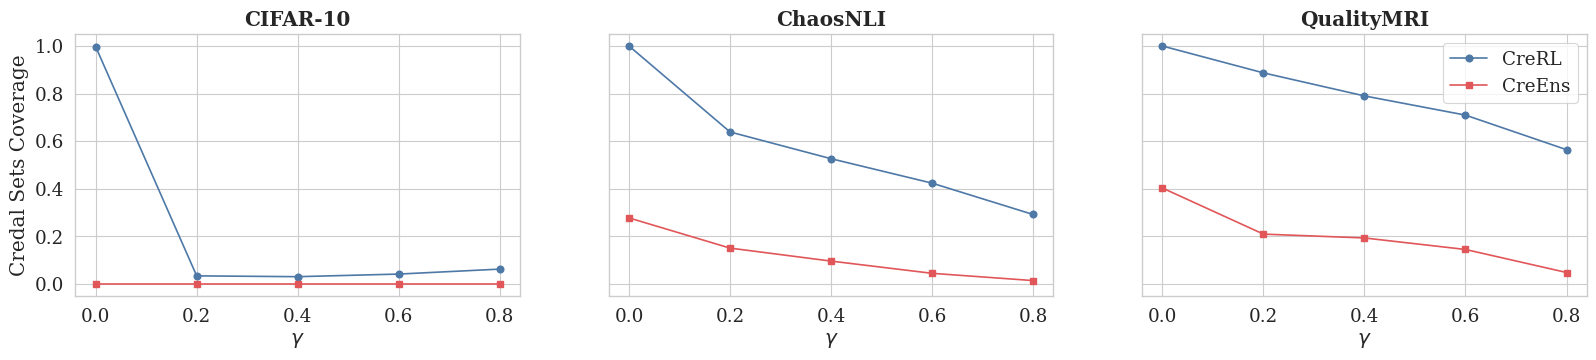

In [4]:
f, axs= make_full_page_figure(style="ICML", n_cols=3, relative_figsize=(3, 2), sharey=True)

for d, dataset in enumerate(["cifar10", "chaosnli", "qualitymri"]):
    for model in ["RL_credal", "destercke"]:
        cvg_model = []
        for gamma in gammas:
            with open(os.path.join(root_path, "all_credal_predictions", dataset, model, str(model_seed), str(gamma), "predictions.pkl"), 'rb') as f:
                predictions = pickle.load(f)
            cvg_model.append(coverage_convex_hull(predictions["outputs"], predictions["targets_p"]))
        axs[d].plot(gammas, cvg_model, label=model, color=colorblind_codes["blue"] if model == "RL_credal" else colorblind_codes["red"], marker="o" if model == "RL_credal" else "s")
        axs[d].set_xlabel(r"$\gamma$")
    
    if d == 0:
        axs[d].set_ylabel("Credal Sets Coverage")
    axs[d].set_title(["CIFAR-10", "ChaosNLI", "QualityMRI"][d], fontweight="bold")
axs[d].legend(["CreRL", "CreEns"])
    # axs[d].tick_params(axis='x', labelsize=8)
os.makedirs(os.path.join(root_path, "all_figures", "unknown_validity"), exist_ok=True)
# plt.savefig(os.path.join(root_path, "all_figures", "unknown_validity", "credal_sets_coverage.pdf"), format="pdf", bbox_inches='tight', pad_inches=0)
            

1. Histogram comparison 

For the main paper, let's pick gamma=0.4 and model_seed=3 and compare the histogram of different CP models 

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def make_full_page_figure(style, n_rows=1, n_cols=1, relative_figsize=(1, 1), **kwargs):
    sns.set_theme(**sns_contexts[style])
    figsize = figsizes[style]["full"]
    figsize = (figsize[0] * relative_figsize[0], figsize[1] * relative_figsize[1])
    f, axs = plt.subplots(n_rows, n_cols, figsize=figsize, **kwargs)
    axs_iter = np.atleast_1d(axs).flat

    for ax in axs_iter:
        # Show only x and y spines
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(True)
        ax.spines["bottom"].set_visible(True)

                # Set spine colors to black
        ax.spines["left"].set_color("black")
        ax.spines["bottom"].set_color("black")

        # Remove ticks and labels
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")

        ax.grid(False)

    return f, axs

In [6]:
methods = ["BPS_no_calib", "BPS_cond_cvg_satisfaction", "BPS_cond_cvg_satisfaction_zero", "BPS_mean_cond_cvg", "BPS_marg_cvg"]
methods = ["BPS_no_calib", "BPS_cond_cvg_satisfaction", "BPS_cond_cvg_satisfaction_zero"]
color_method = {
    "BPS_no_calib": colorblind_codes["red"],
    "BPS_cond_cvg_satisfaction": colorblind_codes["blue"],
    "BPS_cond_cvg_satisfaction_zero": colorblind_codes["orange"],
    "BPS_marg_cvg": colorblind_codes["green"],
}
dataset = "cifar10"
model = "destercke"
model_seed_str = "3"
alphas_credal = 0.4
alpha_cp_str = "0.1"
cond_cvg_thr = 0.9

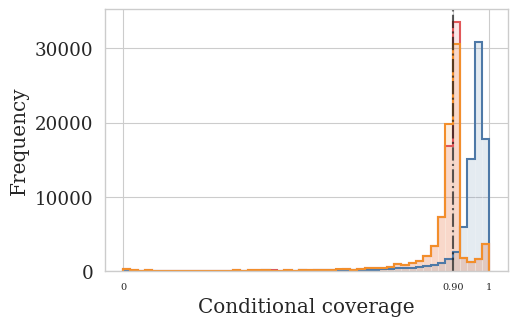

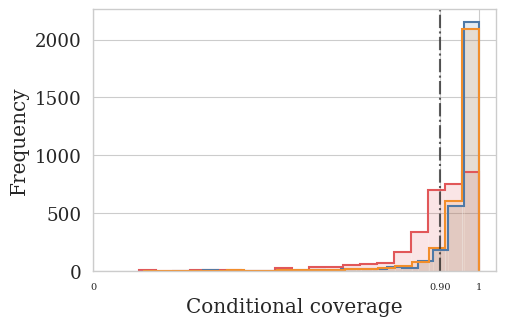

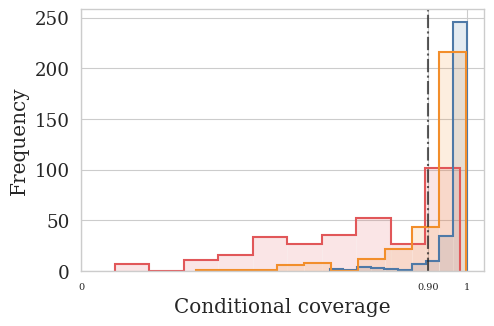

In [7]:
from sklearn.model_selection import train_test_split
from src.BPS import *
for dataset in ["cifar10", "chaosnli", "qualitymri"]:
    if dataset == "cifar10":
        calib_size = 0.2
        bins = 50
    elif dataset == "chaosnli":
        calib_size = 0.50
        bins = 20
    elif dataset == "qualitymri":
        calib_size = 0.5
        bins = 10
    f, axs= make_full_page_figure(style="ICML", n_cols=1, relative_figsize=(0.8, 2))
    for method in methods:
        conditional_cvg = []
        with open(os.path.join(root_path, "all_credal_predictions", dataset, model, model_seed_str, str(alphas_credal), "predictions.pkl"), 'rb') as f:
            predictions = pickle.load(f)
        val_per_seed = []
        for split_seed in range(10):
            calib_credals, test_credals, calib_labels, test_labels, calib_true_probs, test_true_probs = train_test_split(predictions["outputs"], predictions["targets_y"].astype(int), predictions["targets_p"], train_size=calib_size, random_state=2026+split_seed)
            with open(os.path.join(root_path, "all_sets", "unknown validity", dataset, model, model_seed_str, str(alphas_credal), f"alphaCP_{alpha_cp_str}_cond_{cond_cvg_thr}_seed_{split_seed}.pkl"), 'rb') as f:
                results = pickle.load(f)
            sets = results["sets"][method]
            conditional_cvg.append(cond_cvg(sets, test_true_probs))
        axs.hist(np.array(conditional_cvg).flatten(), bins=bins, alpha=0.15,  color=color_method[method])
        axs.hist(np.array(conditional_cvg).flatten(), bins=bins, linewidth=1.5, histtype='step', alpha=1, label=method, fill=False, edgecolor=color_method[method])
    axs.axvline(cond_cvg_thr, c="k", linewidth=1.5, alpha=0.7, linestyle="-.")
    axs.set_xticks([0, cond_cvg_thr, 1])
    axs.set_xticklabels(["0", f"{cond_cvg_thr:.2f}", "1"])
    axs.tick_params(axis='x', labelsize=7)
    # axs.set_xlim([0.5,1])
    # axs.set_ylim([0,50])
    axs.set_xlabel("Conditional coverage")
    axs.set_ylabel("Frequency")
    # axs.grid(True)
    # plt.legend()
    # os.makedirs(os.path.join(root_path, "all_figures", "unknown_validity", "histogram"), exist_ok=True)
    # plt.savefig(os.path.join(root_path, "all_figures", "unknown_validity", "histogram", f"{model}_{dataset}.pdf"), format="pdf", bbox_inches='tight', pad_inches=0)

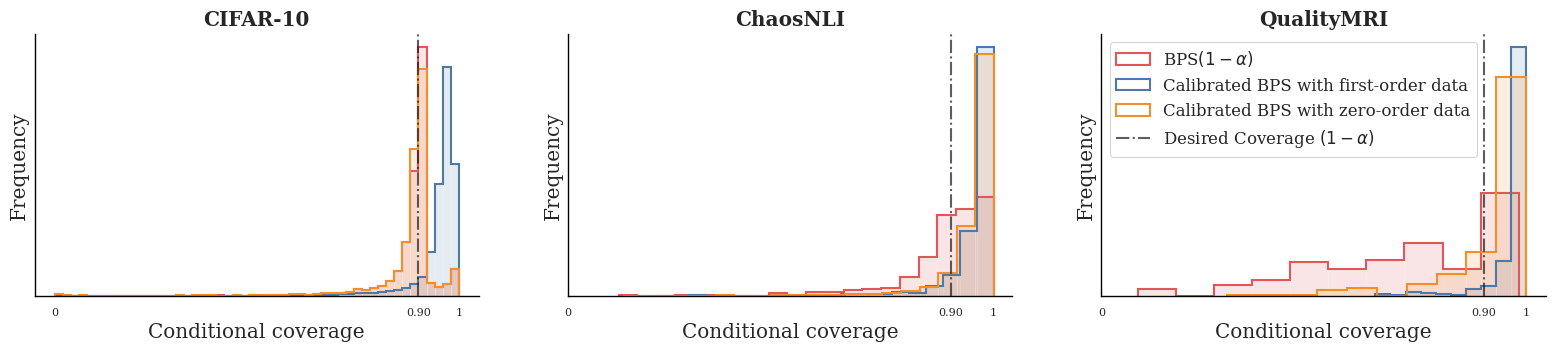

In [15]:
from sklearn.model_selection import train_test_split
from src.BPS import *
f, axs= make_full_page_figure(style="ICML", n_cols=3, relative_figsize=(3, 2))
plt.rcParams["font.size"] = 5000000
for d, dataset in enumerate(["cifar10", "chaosnli", "qualitymri"]):
    if dataset == "cifar10":
        calib_size = 0.2
        bins = 50
    elif dataset == "chaosnli":
        calib_size = 0.50
        bins = 20
    elif dataset == "qualitymri":
        calib_size = 0.5
        bins = 10
    
    for method in methods:
        conditional_cvg = []
        with open(os.path.join(root_path, "all_credal_predictions", dataset, model, model_seed_str, str(alphas_credal), "predictions.pkl"), 'rb') as f:
            predictions = pickle.load(f)
        val_per_seed = []
        for split_seed in range(10):
            calib_credals, test_credals, calib_labels, test_labels, calib_true_probs, test_true_probs = train_test_split(predictions["outputs"], predictions["targets_y"].astype(int), predictions["targets_p"], train_size=calib_size, random_state=2026+split_seed)
            with open(os.path.join(root_path, "all_sets", "unknown validity", dataset, model, model_seed_str, str(alphas_credal), f"alphaCP_{alpha_cp_str}_cond_{cond_cvg_thr}_seed_{split_seed}.pkl"), 'rb') as f:
                results = pickle.load(f)
            sets = results["sets"][method]
            conditional_cvg.append(cond_cvg(sets, test_true_probs))
        axs[d].hist(np.array(conditional_cvg).flatten(), bins=bins, alpha=0.15,  color=color_method[method])
        axs[d].hist(np.array(conditional_cvg).flatten(), bins=bins, linewidth=1.5, histtype='step', alpha=1, label=method, fill=False, edgecolor=color_method[method])
    axs[d].axvline(cond_cvg_thr, c="k", linewidth=1.5, alpha=0.7, linestyle="-.")
    axs[d].set_xticks([0, cond_cvg_thr, 1])
    axs[d].set_xticklabels(["0", f"{cond_cvg_thr:.2f}", "1"])
    # axs[d].set_xlim([0.5,1])
    # axs[d].set_ylim([0,50])
    axs[d].set_xlabel("Conditional coverage")
    axs[d].set_ylabel("Frequency")
    axs[d].set_title(["CIFAR-10", "ChaosNLI", "QualityMRI"][d], fontweight="bold")
    axs[d].tick_params(axis='x', labelsize=8)
# plt.rcParams["font.family"] = "Times New Roman"
# 
axs[-1].legend(["BPS"+r"$(1-\alpha)$", "Calibrated BPS with first-order data", "Calibrated BPS with zero-order data", r"Desired Coverage $(1-\alpha)$"], prop={'size': 12})
os.makedirs(os.path.join(root_path, "all_figures", "unknown_validity", "histogram"), exist_ok=True)
plt.savefig(os.path.join(root_path, "all_figures", "unknown_validity", "histogram", f"{model}_{cond_cvg_thr}.pdf"), format="pdf", bbox_inches='tight', pad_inches=0)